## Model Implementation
This notebook implements simple and multiple linear regression for the string pulling photometry experiments. It also implements cross validation to determine what combination of parameters creates the best model.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy
from sklearn.model_selection import KFold
import scipy.stats as stats
# set font size for plots
plt.rcParams.update({'font.size': 18})

# load and clean the data
phot_data = pd.read_csv("string_phot_rat_data.csv")
data = phot_data.drop(columns=['percentage_x', 'x_reach_centered', 'y_reach_centered', 'rat'])
data = data.dropna()
# seperate data into testing and training dat
# find random indexes that account for around 25% of the data
test_ix = numpy.random.randint(0, data.shape[0],round(data.shape[0]/4))
test_data = data.iloc[test_ix].copy()
# get a list of the indicies to keep in the training data
train_ix = list(set(range(data.shape[0])) - set(test_ix))
train_data = data.iloc[train_ix].copy()

X_train = train_data.drop(columns=['df_centered'])
y_train = train_data['df_centered'].to_numpy()

X_test = test_data.drop(columns=['df_centered'])
y_test = test_data['df_centered'].to_numpy()

In [478]:
def linear_regression_gradient_descent(X, y):
    '''This function takes an X that is a pandas dataframe of paramters and a y that is a numpy array. 
        It then performs linear regression from variables in X onto y using gradient descent and outputs
        The weights and biases.'''
    # check if there are multiple parameters
    if len(X.shape) > 1:
        n_samples, n_features = X.shape
        weights = numpy.zeros(n_features)
    else:
        n_samples = X.size
        n_features = 1
        weights = 0
    # implement gradient descent
    # set initial weights and biases
    bias = 1
    learning_rate = 0.001
    epochs = 10000

    # fit the model
    for epoch in range(epochs):
        # calculate predicted y
        y_predicted = numpy.dot(X, weights) + bias
        # get the error for weights and bias
        diff_w = (1/n_samples) * numpy.dot(X.T, (y_predicted - y))
        diff_b = (1/n_samples) * numpy.sum(y_predicted - y)  

        # update weights and biases
        weights -= learning_rate*diff_w
        bias -= learning_rate*diff_b
    return weights, bias


def calculate_RSE(y_pred, y, n_sample, n_params):
    '''Calculates the root squared error using numpy arrays y-pred and y, 
        where y_pred is predicted values of y 
        and integer number of samples, n_sample, and number of parameters
        n_params. Returns the root squared error as a float.'''
    rss = numpy.sum((y_pred - y)**2)
    rse = numpy.sqrt(rss/(n_sample-n_params-1))
    return rse

def calculate_R2(y, y_pred):
    '''Calcualtes the r^2 given numpy arrays y and y_pred, where y_pred is
        predicted values of y. Returns a r^2 as a float.'''
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    RSS = numpy.sum(numpy.square(y - y_pred))
    R2 = 1 - (RSS/TSS)
    return R2

def calculate_adjusted_R2(y, y_pred, n, p):
    '''Calculates an adjusted r^2 value for cross validation between models
        with different numbers of parameters. Takes numpy arrays y and y_pred, 
        where y_pred is predicted values of y. Returns the adjusted r^2 as a
        float.'''
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    RSS = numpy.sum(numpy.square(y - y_pred))
    R2 = 1 - ((RSS/(n - p - 1))/(TSS/(n - 1)))
    return R2


def calculate_F(y, y_pred, n_features, n_samples):
    '''Calculates the values of the f-statistic using numpy arrays y and y_pred, 
        where y_pred is predicted values of y, the floats n_features and n_samples,
        which are the number of features and the number of samples, respectively.
        Returns the value of the f-statistic as a float.'''
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    RSS = numpy.sum(numpy.square(y-y_pred))
    F = ((TSS-RSS)/n_features)/((RSS)/(n_samples - n_features - 1))
    return F


def k_fold_cross_val(X, y, n_samples, n_params):
    '''Do k fold cross validation with 5 splits for x and y. Takes X which is
        a pandas dataframe with the parameters as columns, y which is the output
        for the regression, n_samples and n_params wich are integer represenations
        of the number of parameters and samples respectively. Runs linear regression
        with gradient descent and calculates RSE and adjusted r^2 for all 5 folds. 
        Returns the average RSE value and average adjusted r^2 value as floats.'''
    # create the 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    r2s = []
    adj_r2s = []
    # loop through the folds
    for trainIX, testIX in kf.split(y):
        train_X, test_X = X[trainIX], X[testIX]
        train_y, test_y = y[trainIX], y[testIX]
        # run gradient descent on the training data
        weight, bias = linear_regression_gradient_descent(train_X, train_y)
        # calculate predicted values
        y_pred = numpy.dot(test_X, weight) + bias
        r2 = calculate_R2(test_y, y_pred)
        r2s.append(r2)
        adjusted_R2 = calculate_adjusted_R2(test_y, y_pred, len(test_y), n_params)
        adj_r2s.append(adjusted_R2)
        # calculate and return average rse and r^2
    rse =  numpy.mean(r2s)
    adj_r2 = numpy.mean(adj_r2s)
    return rse, adj_r2       

In [ ]:
def simple_reg_for_each_parameter(X_df, y):
    '''Runs simple linear regression for each column of X_df, which is a pandas dataframe.
        Y is the output varaible for the regression as a numpy array. Creates and returns
        a dictionary of the RSE and r^2 values for each simple regression.'''    
    simple_reg_dict = {}
    # loop through each parameter in the dataframe
    for param in X_df.columns:
        # get just the selected column and convert it to a numpy array
        X = X_df[param].to_numpy()
        rse, adj_r2 = k_fold_cross_val(X, y, X.size, 1)
        # add output of cross validation to a dictionary
        simple_reg_dict[param] = [rse, adj_r2]
    return simple_reg_dict

In [476]:
def simple_reg_for_each_parameter_eval(X_train, y_train, X_test, y_test): 
    '''Runs simple linear regression for each column of X_train using gradient descent. Tests it using X_test
        and y_test, calcuates the f-statistic and p-value. Returns the weight, bias, f-statistic, and p-value for
        simple regression of each parameter in a dictionary with the parameter as the key. Also plots the regression.
        X_test, and X_train should be numpy arrays with the parameters as columns, y_train and y_test and 1d numpy arrays.'''   
    simple_reg_dict = {}
    # a list of x labels for the graphs
    x_labels = ['X displacement (cm)', 'Y displacement(cm)', 'Effort (relative)', 'String Speed (cm/s)', 'Paw Speed (cm/s)']
    # an index variable to use for the x labels
    i = 0
    # loop through each parameter in x_train
    for param in X_train.columns:
        # get the train x and test x as numpy arrays for selected parameter
        X = X_train[param].to_numpy()
        test_X = X_test[param].to_numpy()
        weight, bias = linear_regression_gradient_descent(X, y_train)
        # get predicted y values
        y_pred = weight*test_X + bias
        residuals = y_pred - y_test
        F = calculate_F(y_test, y_pred, X_test.shape[1], X_test.shape[0])
        # calcuate the p-value from the f statistic and appropriate degrees of freedom
        p_val = 1 - stats.f.cdf(F, 1, X_test.shape[0] - 2)
        simple_reg_dict[param] = [bias, weight, F, p_val]
        plt.figure()
        plt.scatter(X_test[param], y_test, alpha=0.7)
        plt.axline(xy1=(0,bias), slope=weight, color='red', linewidth=5)
        plt.xlabel(x_labels[i])
        plt.ylabel('change in fluorescence')
        i += 1

    return pd.DataFrame(simple_reg_dict)

,x_pos_centered,y_pos_centered,effort_centered,rot_centered,paw_vel_centered
0,5.885111e-05,6.030219e-05,0.000060,5.865779e-05,5.978077e-05
1,-1.482606e-03,-6.338214e-04,-0.000118,-4.316270e-05,-2.930818e-05
2,1.440334e+02,7.956887e+01,-0.688037,3.322137e+01,3.533783e+01
3,1.110223e-16,1.110223e-16,1.000000,8.296518e-09,2.799476e-09


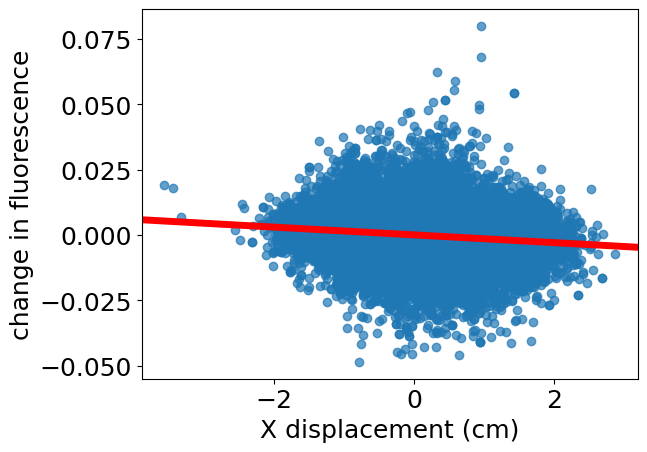

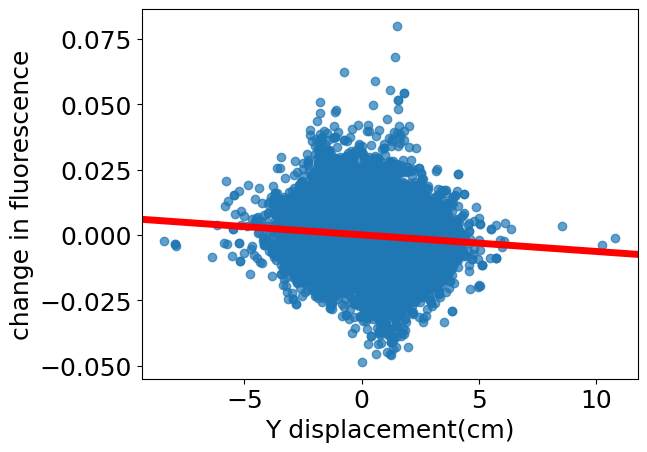

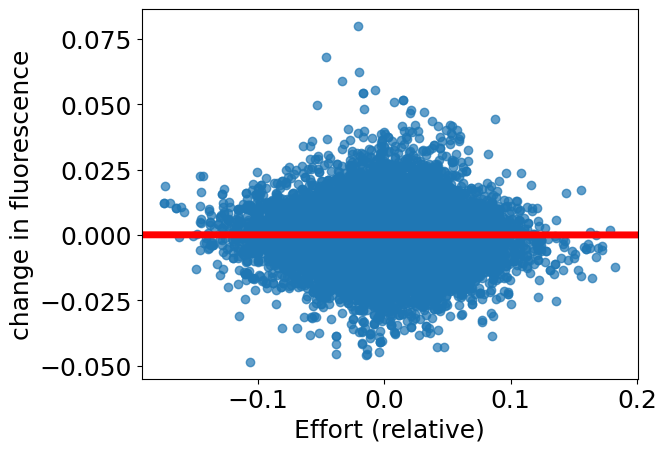

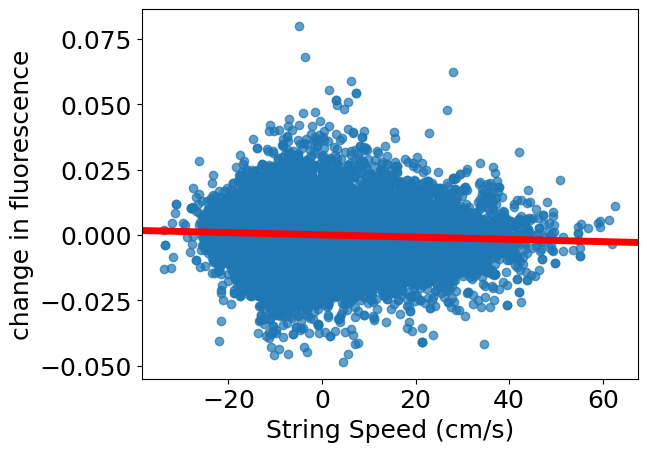

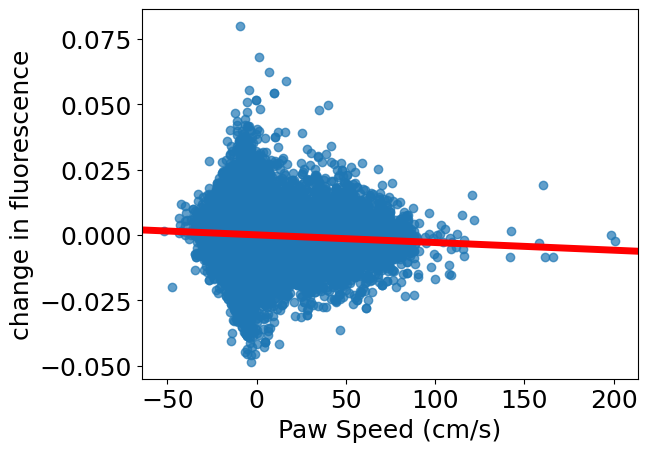

In [479]:
simple_reg_for_each_parameter_eval(X_train, y_train, X_test, y_test)

In [ ]:
# get a pandas dataframe of only the training data
X_df = train_data.drop(columns=['df_centered'])
X = X_df.to_numpy()
y = train_data['df_centered'].to_numpy()

simple = simple_reg_for_each_parameter(X_df, y)
# convert the dictionary into a dataframe so it is easy to read
pd.DataFrame(simple, index=['r2', 'adj_r2']).head()

,x_pos_centered,y_pos_centered,effort_centered,rot_centered,paw_vel_centered
rse,0.017850,0.011026,-0.000036,0.003355,0.004330
adj_r2,0.017802,0.010979,-0.000084,0.003307,0.004282


In [485]:
def multiple_linreg(X, y):
    '''Runs linear regression with cross validation for an X pandas dataframe with at least
        two parameters as columns and a numpy array y as output. Returns the RSE and adjusted
        r^2 from cross validation.'''
    n_samples, n_features = X.shape
    r2, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
    return r2, adj_r2

In [486]:
r2s = []
adj_r2s = []
# run k fold cross validation on all 2 parameter models containing x paw postion
for param in X_df.drop(columns=['x_pos_centered']).columns:
        params = ['x_pos_centered']
        params.append(param)
        X = X_df[params].to_numpy()
        n_samples, n_features = X.shape
        r2, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
        r2s.append(r2)
        adj_r2s.append(adj_r2)
pd.DataFrame([r2s, adj_r2s], index=['R^2', 'adjusted R^2'], columns=X_df.drop(columns=['x_pos_centered']).columns)

,y_pos_centered,effort_centered,rot_centered,paw_vel_centered
R^2,0.020108,0.017856,0.017823,0.017877
adjusted R^2,0.020013,0.017762,0.017729,0.017783


In [487]:
r2s = []
adj_r2s = []
# run k fold cross validation for all 3rd parameters added to x position and y position
for param in X_df.drop(columns=['x_pos_centered', 'y_pos_centered']).columns:
        params = ['x_pos_centered', 'y_pos_centered']
        params.append(param)
        X = X_df[params].to_numpy()
        n_samples, n_features = X.shape
        r2, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
        r2s.append(r2)
        adj_r2s.append(adj_r2)
pd.DataFrame([r2s, adj_r2s], index=['R^2', 'adjusted R^2'], columns=X_df.drop(columns=['x_pos_centered', 'y_pos_centered']).columns)

,effort_centered,rot_centered,paw_vel_centered
R^2,0.020119,0.020089,0.020063
adjusted R^2,0.019978,0.019947,0.019922


In [489]:
r2s = []
adj_r2s =[]
# run k fold cross validation for all 4th parameters after x position, y position, and string speed
for param in X_df.drop(columns=['x_pos_centered', 'y_pos_centered', 'rot_centered']).columns:
        params = ['x_pos_centered', 'y_pos_centered', 'rot_centered']
        params.append(param)
        X = X_df[params].to_numpy()
        n_samples, n_features = X.shape
        r2, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
        r2s.append(r2)
        adj_r2s.append(adj_r2)
pd.DataFrame([r2s, adj_r2s], index=['R^2', 'adjusted R^2'], columns=X_df.drop(columns=['x_pos_centered', 'y_pos_centered', 'rot_centered']).columns)

,effort_centered,paw_vel_centered
R^2,0.020101,0.020054
adjusted R^2,0.019912,0.019865


In [484]:
n_samples, n_features = X_df.shape
# k fold cross validation for a model with all varaibles
r2, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
print('r^2: ' + str(r2))
print('adjusted r^2: ' + str(adj_r2))

r^2: 0.0200537032709591
adjusted r^2: 0.019817746756602573


In [471]:
def multiple_linreg_eval(X, y, X_test, y_test, title_str):
    '''Does linear regression with gradient descent using X and y, then tests it on
        X_test and y_test, calculates an f-statistic, p-value, and plots a residual plot. 
        X and X_test are pandas dataframes with parameters as columns, y and y_test are 
        numpy arrays. title_str is the title of the residuals figure. It returns the bias, 
        weights, f-statistic, and p-value for the model.'''
    n_samples, n_features = X.shape
    weights, bias = linear_regression_gradient_descent(X, y)
    test_X = X_test.to_numpy()
    y_pred = numpy.dot(test_X, weights) + bias
    residuals = y_pred - y_test
    f = calculate_F(y_test, y_pred, X_test.shape[1], X_test.shape[0])
    p_val = 1 - stats.f.cdf(f, X_test.shape[1], X_test.shape[0] - X_test.shape[1])
    plt.figure()
    plt.scatter(y_pred, residuals, alpha=0.7)
    plt.xlabel('Predicted y values')
    plt.ylabel('Residuals')
    plt.title(title_str)
    return bias, weights, f, p_val

bias: 5.9426393794031844e-05
weights: [-1.05601475e-03 -3.57571948e-04 -8.11607546e-05 -4.41964307e-06
 -3.07918152e-06]
F-statistic: 158.37981055795976
p-value: 1.1102230246251565e-16


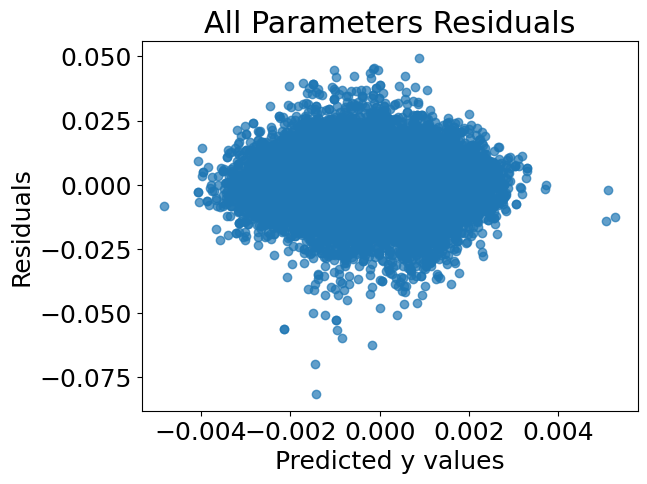

In [472]:
bias, weight, f, p_val = multiple_linreg_eval(X_train, y_train, X_test, y_test, 'All Parameters Residuals')
print('bias: ' + str(bias))
print('weights: ' + str(weight))
print('F-statistic: ' + str(f))
print('p-value: ' + str(p_val))

bias: 5.940167705524126e-05
weights: [-0.00117455 -0.00033483]
F-statistic: 395.09620622741915
p-value: 1.1102230246251565e-16


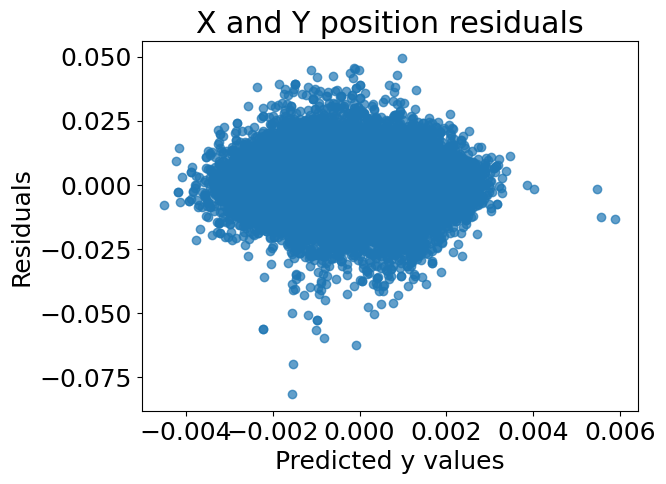

In [473]:
bias, weight, f, p_val =  multiple_linreg_eval(X_train[['x_pos_centered', 'y_pos_centered']], y_train, 
                                               X_test[['x_pos_centered', 'y_pos_centered']], y_test, 'X and Y position residuals')

print('bias: ' + str(bias))
print('weights: ' + str(weight))
print('F-statistic: ' + str(f))
print('p-value: ' + str(p_val))

bias: 5.931022617043979e-05
weights: [-1.14281186e-03 -3.36803182e-04 -4.63206715e-06]
F-statistic: 264.886933333812
p-value: 1.1102230246251565e-16


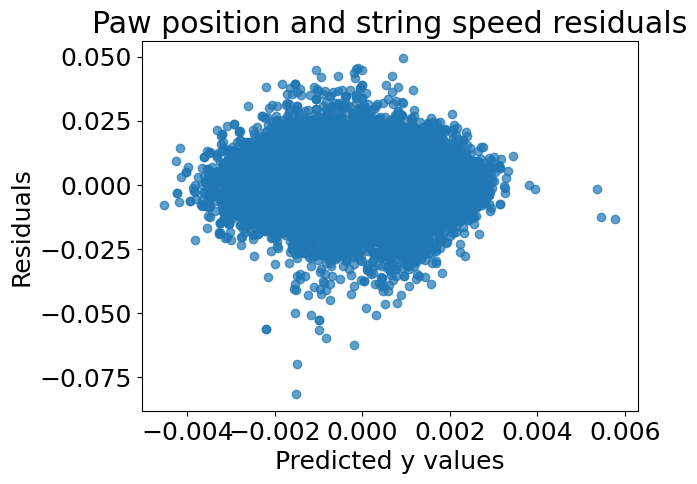

In [474]:
bias, weight, f, p_val = multiple_linreg_eval(X_train[['x_pos_centered', 'y_pos_centered', 'rot_centered']], y_train, 
                            X_test[['x_pos_centered', 'y_pos_centered', 'rot_centered']], y_test, 'Paw position and string speed residuals')
print('bias: ' + str(bias))
print('weights: ' + str(weight))
print('F-statistic: ' + str(f))
print('p-value: ' + str(p_val))

bias: 5.9426276285645075e-05
weights: [-1.05701618e-03 -3.57409437e-04 -4.35171201e-06 -3.07656837e-06]
F-statistic: 197.82306749016828
p-value: 1.1102230246251565e-16


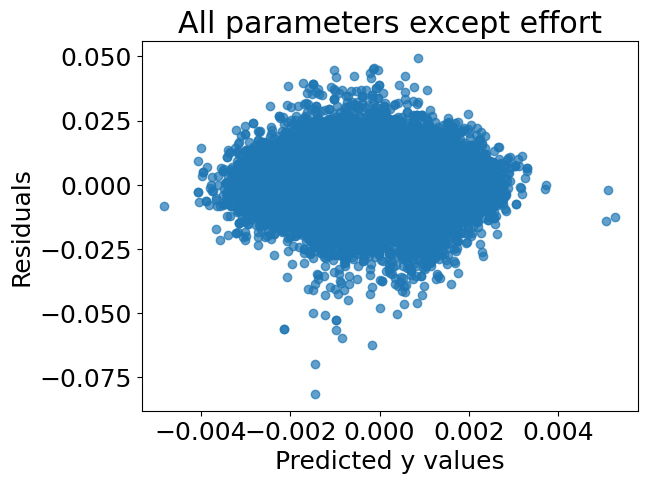

In [475]:
bias, weight, f, p_val = multiple_linreg_eval(X_train[['x_pos_centered', 'y_pos_centered', 'rot_centered', 'paw_vel_centered']],
                            y_train, X_test[['x_pos_centered', 'y_pos_centered', 'rot_centered', 'paw_vel_centered']], y_test, 'All parameters except effort')
print('bias: ' + str(bias))
print('weights: ' + str(weight))
print('F-statistic: ' + str(f))
print('p-value: ' + str(p_val))